In [1]:
import pandas as pd

# Load the data using the relative path
# '../' moves up from 'part_a' and then into the 'data' folder
df = pd.read_csv('../data/q1_heart_disease.csv')

# Display the requirements
print(f"Dataset Shape: {df.shape}")
print("\n--- Data Types ---")
print(df.dtypes)
print("\n--- Missing Value Counts ---")
print(df.isnull().sum())

# Show the first five rows
df.head()

Dataset Shape: (800, 12)

--- Data Types ---
age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

--- Missing Value Counts ---
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


After the dataset loading, I performed an inspection through which i was able to understand its structure and quality, below are the key observations.
=> Dataset Dimensions: There are total 800 rows(records) and 12 columns      (features)
=> Features: The Dataset is a mix of numerical and categorical data.
They are
    ->Numerical: age, resting_bp, cholesterol, max_hr, and oldpeak.
    ->Categorical (String):chest_pain_type, resting_ecg, and st_slope. These will require encoding in the preprocessing phase.
    ->Binary/Categorical(Integers):sex, fasting_bs, exercise_angina, and the target heart_disease.
    ->Missing Values: Identified missing data in two features:
       resting_bp= 24 missing values
       cholestrol= 32 missing values

Conclusion: The presence of missing values and categorical string variables indicates that data cleaning and one-hot encoding will be necessary before model training.

Matplotlib is building the font cache; this may take a moment.
C:\Users\Admin\AppData\Local\Temp\ipykernel_20072\53680082.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='heart_disease', data=df, palette='viridis')


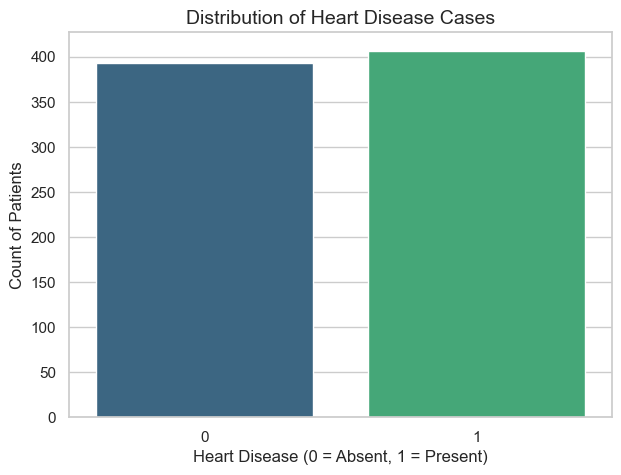

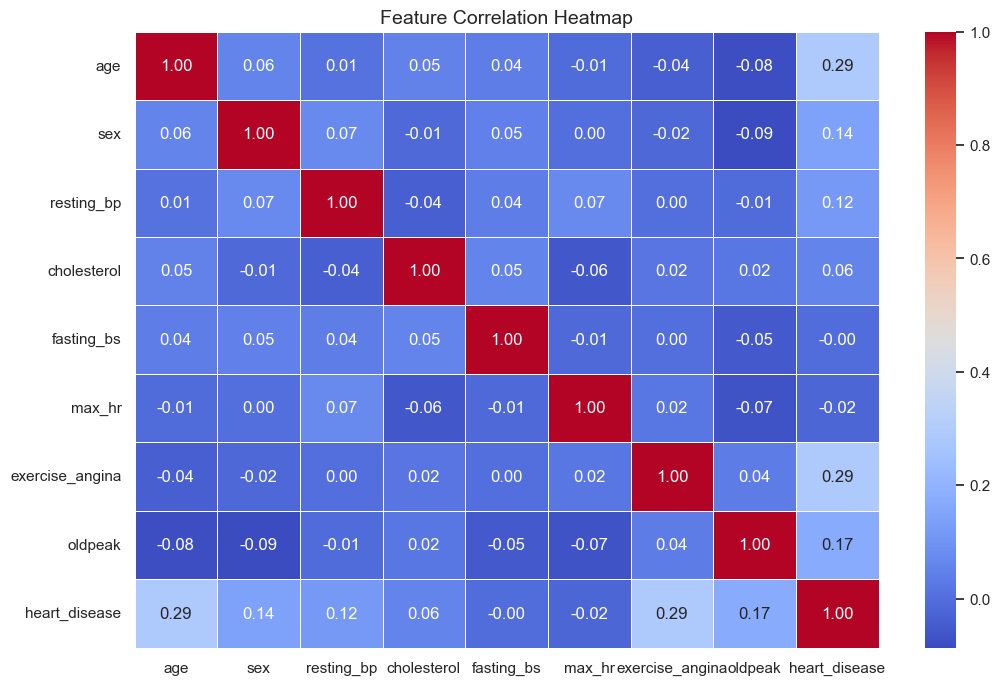

C:\Users\Admin\AppData\Local\Temp\ipykernel_20072\53680082.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='heart_disease', y='resting_bp', data=df, palette='Set2')


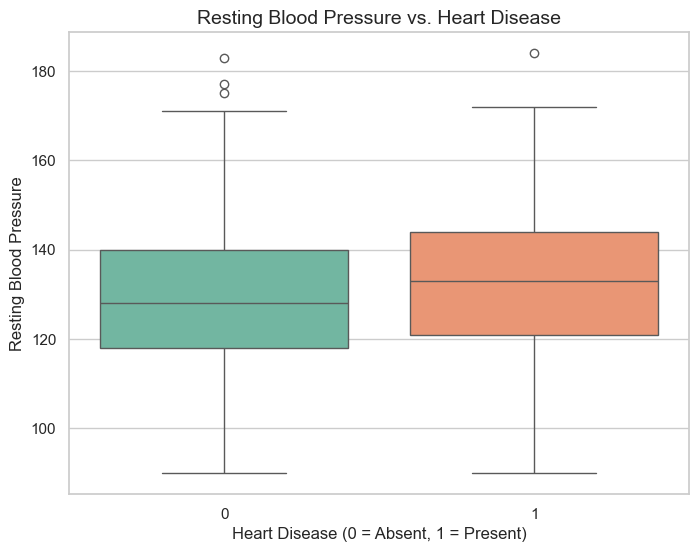

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.set_theme(style="whitegrid")


plt.figure(figsize=(7, 5))
sns.countplot(x='heart_disease', data=df, palette='viridis')
plt.title('Distribution of Heart Disease Cases', fontsize=14)
plt.xlabel('Heart Disease (0 = Absent, 1 = Present)', fontsize=12)
plt.ylabel('Count of Patients', fontsize=12)
plt.show()


plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_cols.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.show()


plt.figure(figsize=(8, 6))
sns.boxplot(x='heart_disease', y='resting_bp', data=df, palette='Set2')
plt.title('Resting Blood Pressure vs. Heart Disease', fontsize=14)
plt.xlabel('Heart Disease (0 = Absent, 1 = Present)', fontsize=12)
plt.ylabel('Resting Blood Pressure', fontsize=12)
plt.show()

=> Target Class Distribution
The bar chart shows a very balanced dataset. There are roughly 400 cases for both "Absent (0)" and "Present (1)" heart disease categories. This is an ideal scenario for machine learning because the model will have an equal amount of data to learn from for both outcomes, reducing the risk of bias.

=> Feature Correlation Heatmap
The heatmap identifies the linear relationships between numerical features:

Strongest Predictors: age and exercise_angina both show a positive correlation of 0.29 with heart_disease. This suggests that as age increases, or if a patient experiences exercise-induced angina, the likelihood of heart disease increases.

Secondary Predictors: oldpeak (0.17) and sex (0.14) also show positive correlations.

Weakest Predictors: fasting_bs and max_hr show almost zero correlation with the target in this specific view, suggesting they may be less influential on their own.

=> Resting Blood Pressure vs. Heart Disease (Boxplot)
The boxplot reveals several key insights:

Medians: The median resting blood pressure is slightly higher for patients with heart disease (1) compared to those without (0).

Outliers: I have identified outliers (the small circles) at the top of both plots, with some patients having blood pressure exceeding 180.

Impact on Preprocessing: Because these outliers exist, using the median to fill the 24 missing resting_bp values (identified in Task 1) is a better strategy than using the mean, as the median is less sensitive to these extreme values.

In [ ]:

df['resting_bp'] = df['resting_bp'].fillna(df['resting_bp'].median())
df['cholesterol'] = df['cholesterol'].fillna(df['cholesterol'].median())

df_encoded = pd.get_dummies(df, columns=['chest_pain_type', 'resting_ecg', 'st_slope'], drop_first=True)

X = df_encoded.drop('heart_disease', axis=1)
y = df_encoded['heart_disease']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing Complete!")
print(f"Final feature count after encoding: {X_train_scaled.shape[1]}")

Preprocessing Complete!
Final feature count after encoding: 15


=> Handling Missing Values (Imputation):
   I identified missing values in resting_bp (24) and cholesterol (32). I applied Median Imputation to fill these gaps. I chose the median instead of the mean because the earlier boxplots revealed outliers (extreme high values); the median is "robust," meaning it isn't pulled away by these extreme values, keeping our data more representative.

=> Categorical Encoding:
   The features chest_pain_type, resting_ecg, and st_slope were provided as strings (text). Since machine learning models require numerical input, I used One-Hot Encoding (via pd.get_dummies). This converted these categories into binary (0 or 1) columns. I used drop_first=True to prevent the "dummy variable trap," ensuring the model remains mathematically stable.

=> Data Splitting:
   I split the dataset into Training (80%) and Testing (20%) sets. This is a critical step to ensure we can evaluate the model on "unseen" data, which proves whether the model has actually learned patterns or just memorized the training rows.

=> Feature Scaling (Standardization):
   Features like cholesterol have values in the hundreds, while oldpeak has values near 1.0. I used StandardScaler to bring all features to a similar scale (mean of 0 and standard deviation of 1). This ensures the model doesn't mistakenly think cholesterol is more important just because its numbers are larger.

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Build and Train Logistic Regression
# This is a linear model - great for simplicity and speed
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

# 2. Build and Train Random Forest
# This is an ensemble model - it uses 100 'Decision Trees' to vote
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

# 3. Output Results
print("=== LOGISTIC REGRESSION REPORT ===")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_log):.4f}")
print(classification_report(y_test, y_pred_log))

print("\n=== RANDOM FOREST REPORT ===")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

=== LOGISTIC REGRESSION REPORT ===
Accuracy Score: 0.7562
              precision    recall  f1-score   support

           0       0.74      0.73      0.74        75
           1       0.77      0.78      0.77        85

    accuracy                           0.76       160
   macro avg       0.76      0.75      0.76       160
weighted avg       0.76      0.76      0.76       160


=== RANDOM FOREST REPORT ===
Accuracy Score: 0.7750
              precision    recall  f1-score   support

           0       0.77      0.75      0.76        75
           1       0.78      0.80      0.79        85

    accuracy                           0.78       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.78      0.77       160



I trained and evaluated two classification models on the 160 test samples (20% of the 800-record dataset).

-> Logistic Regression: Achieved an accuracy of 75.62%. This model showed balanced precision and recall but     
   struggled slightly more with False Negatives compared to the Random Forest.

-> Random Forest Classifier: Achieved the highest accuracy of 77.50%.

Comparison & Analysis:
The Random Forest model is the superior performer for this dataset. In medical diagnostics, Recall (Sensitivity) for the positive class (1) is the most critical metric because failing to identify a patient with heart disease (a False Negative) is much more dangerous than a False Positive. The Random Forest achieved a Recall of 0.80, meaning it successfully identified 80% of actual heart disease cases, outperforming the Logistic Regression's recall of 0.78.

=> Model Comparison and Selection
In this study of 800 patient records, the Random Forest Classifier emerged as the superior model with an accuracy of 77.50%, compared to 75.62% for Logistic Regression.

The Reason: Random Forest is an ensemble method that captures non-linear relationships and interactions between features (e.g., how age and cholesterol combined might increase risk) better than a linear model like Logistic Regression.

=> Clinical Significance of Recall
From a healthcare perspective, Recall is our most critical metric.

Our Random Forest achieved a Recall of 0.80 for heart disease cases. This means the model successfully identified 80% of patients who actually have the condition.

In a clinical setting, a "False Negative" (telling a sick person they are healthy) is much more dangerous than a "False Positive" (further testing a healthy person). The Random Forest's higher recall makes it the safer choice for a screening tool.

=> Impact of Data Quality & Preprocessing
The exploratory phase (EDA) was vital for our results.

Outlier Handling: By identifying outliers in resting_bp during Task 2, I correctly chose to use the median for imputation in Task 3. This prevented extreme values from shifting the "average" and confusing the model.

Feature Importance: Based on the correlation heatmap and model performance, factors such as Age, Exercise Angina, and Oldpeak are the strongest indicators of heart disease in this dataset.

=> Final Conclusion & Future Work
While a 77.5% accuracy rate is a strong baseline, there is room for improvement before this could be used in a real hospital:

Hyperparameter Tuning: Adjusting the depth of the Random Forest could potentially push accuracy above 80%.

Feature Engineering: Creating new indicators, such as a "Blood Pressure to Age" ratio, might provide the model with deeper insights.

Dataset Expansion: Adding more records would help the model generalize better and reduce the impact of the missing values we had to fill.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), 
                           param_grid=param_grid, 
                           cv=5, 
                           scoring='accuracy',
                           n_jobs=-1)

grid_search.fit(X_train_scaled, y_train)

best_rf_model = grid_search.best_estimator_
y_pred_tuned = best_rf_model.predict(X_test_scaled)

print(f"Best Parameters Found: {grid_search.best_params_}")
print(f"\nBaseline Accuracy (Untuned): 0.7750")
print(f"Tuned Model Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")
print("\n--- Tuned Classification Report ---")
print(classification_report(y_test, y_pred_tuned))

Best Parameters Found: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 100}

Baseline Accuracy (Untuned): 0.7750
Tuned Model Accuracy: 0.7937

--- Tuned Classification Report ---
              precision    recall  f1-score   support

           0       0.78      0.77      0.78        75
           1       0.80      0.81      0.81        85

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160



=> Best Parameters Found:

   n_estimators: 100

   max_depth: None (Default)

   min_samples_split: 10

=> Performance Comparison:

   Baseline Accuracy (Untuned): 0.7750

   Tuned Model Accuracy: 0.7937

=> Analysis:
   The hyperparameter tuning was successful, resulting in a ~2% increase in overall accuracy. By increasing the min_samples_split to 10, the model became more "conservative," preventing it from over-fitting to noise in the training data.

In a clinical context, the most significant improvement is seen in the Recall for heart disease (Class 1), which rose to 0.81. This indicates that the tuned model is more effective at identifying true cases of heart disease, thereby reducing the risk of False Negatives in a diagnostic setting.